This script measures and saves to ROOT files fake factors in a trilepton region.

In [1]:
import numpy as np
import uproot
import matplotlib.pyplot as plt
import matplotlib.colors as clr
import mplhep as hep

Define constants

In [2]:
YEARS = ["2016"]
# YEARS = ["2016APV", "2016", "2017", "2018"]
# SAMPLES = ["test"]
SAMPLES = ["Data", "TX", "VV", "DY", "TT"]
CHARGES = ["OS", "SS"]
CHANNELS = ["ee", "emu", "mumu"]
REGIONS = ["ll", "llStl300", "llMetg20Jetgeq1B0"]
# REGIONS = ["llStl300", "llMetg20Jetgeq1B0"]
VARS = ["geqTightTa", "geqTightFakeTa", "lTightTa", "lTightFakeTa"]
DIFFS = ["vsPt", "vsEta", "vsPt_vsEta"]
DIFF_1DLIMS = [(20.0, 220.0), (0.0, 2.3)]
DIFF_AXLABELS = [r"Tau $p_{T}$", r"Tau $\eta$"]
LUMI = ["19.5", "16.8", "41.5", "59.8"]

Open ROOT files

In [3]:
%%time
h = {}
for year in YEARS:
    for sample in SAMPLES:
        fname = "../hists/TrileptonFF/" + year + "_" + sample + ".root"
        print("Opening " + fname)
        file = uproot.open(fname)
        for charge in CHARGES:
            for channel in CHANNELS:
                for region in REGIONS:
                    for var in VARS:
                        for diff in DIFFS:
                            hname = charge + "_" + channel + "_" + region + "_" + var + "_" + diff
                            temp = file[hname].to_pyroot() # TODO: what to do about overflow bin?

                            # Set negative event counts due to NLO low statistics to 0 in 1D histograms
                            if diff!="vsPt_vsEta":
                                for i in range(1, temp.GetNbinsX() + 1):
                                    if temp.GetBinContent(i) < 0.0:
                                        temp.SetBinContent(i, 0.0)
                                        temp.SetBinError(i, 0.0)
                            # Set negative event counts due to NLO low statistics to 0 in 2D histograms
                            else:
                                for i in range(1, temp.GetNbinsX() + 1):
                                    for j in range(1, temp.GetNbinsY() + 1):
                                        if temp.GetBinContent(i, j) < 0.0:
                                            temp.SetBinContent(i, j, 0.0)
                                            temp.SetBinError(i, j, 0.0)

                            h[year + "_" + sample + "_" + hname] = temp
        file.close()

Opening ../hists/TrileptonFF/2016_Data.root
Welcome to JupyROOT 6.28/06
Opening ../hists/TrileptonFF/2016_TX.root
Opening ../hists/TrileptonFF/2016_VV.root
Opening ../hists/TrileptonFF/2016_DY.root
Opening ../hists/TrileptonFF/2016_TT.root
CPU times: user 4.5 s, sys: 1.35 s, total: 5.85 s
Wall time: 17.3 s


1D fake tau purity

<timed exec>:20: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.


CPU times: user 21.7 s, sys: 11.4 s, total: 33.1 s
Wall time: 23 s


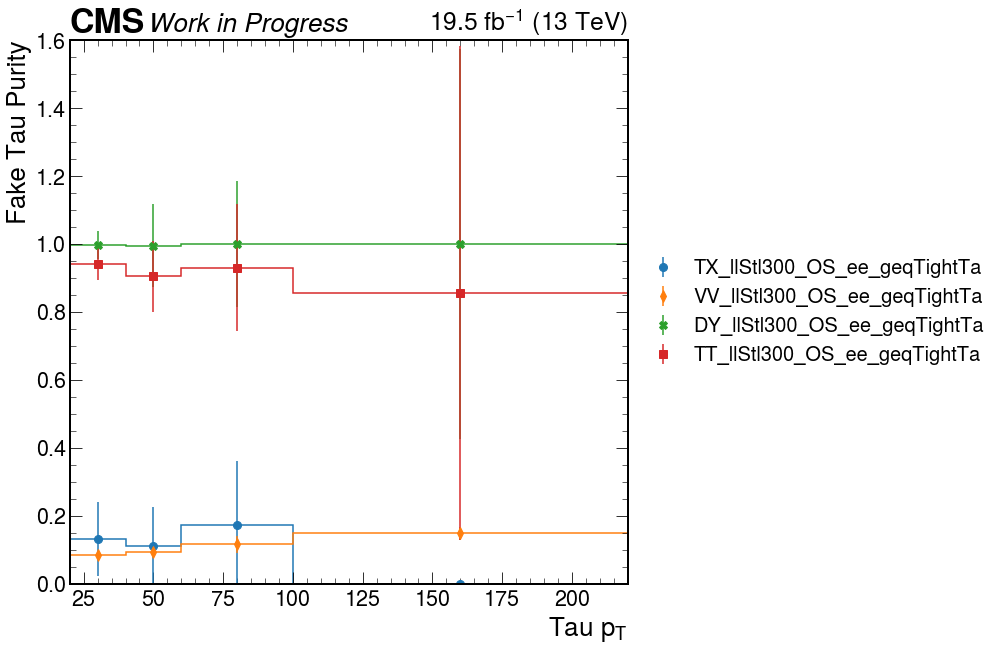

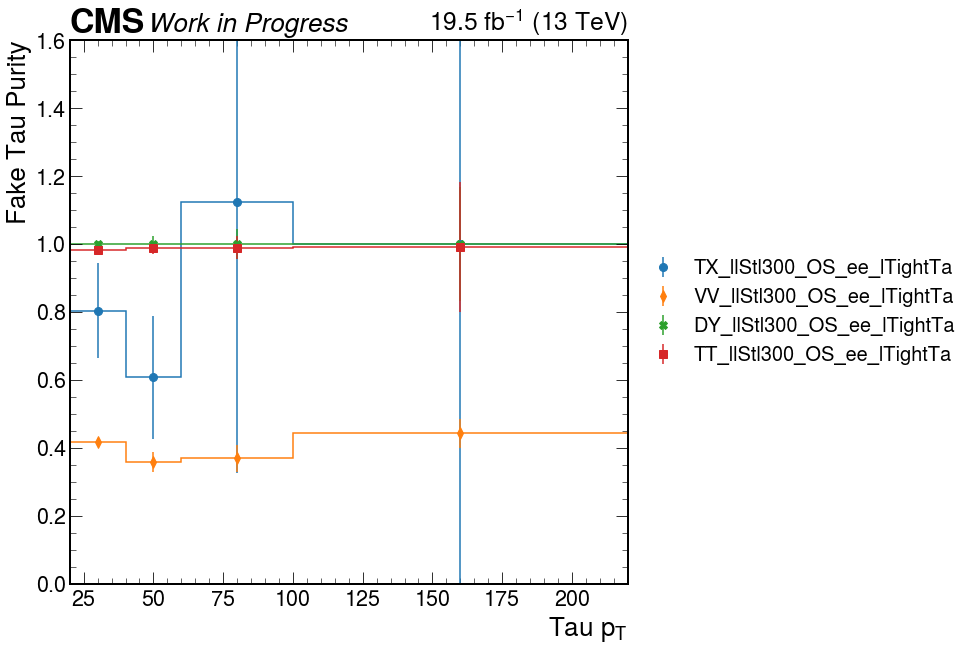

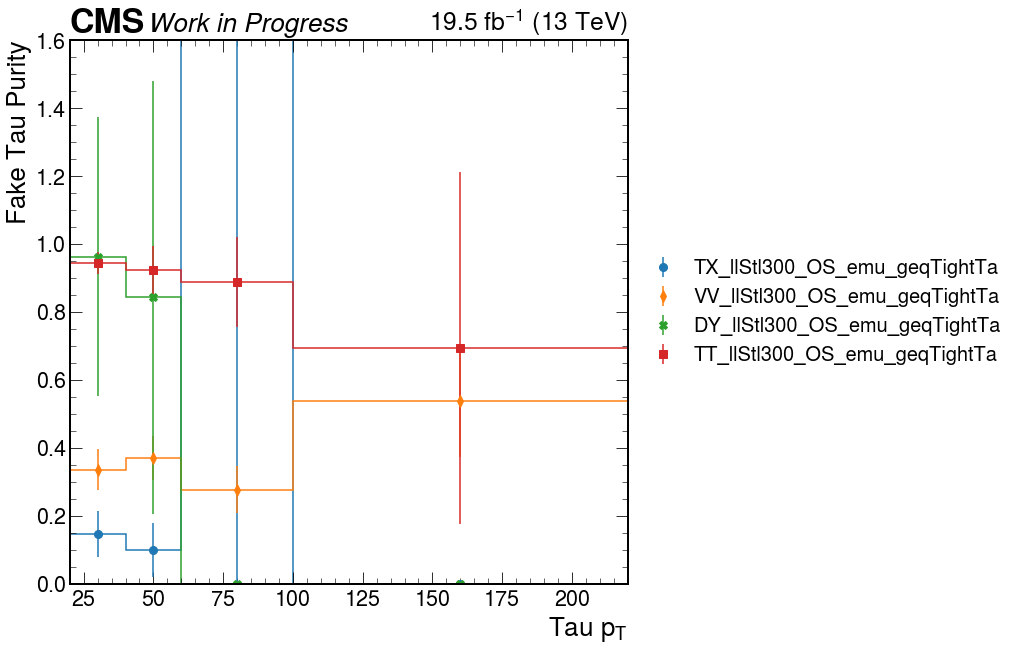

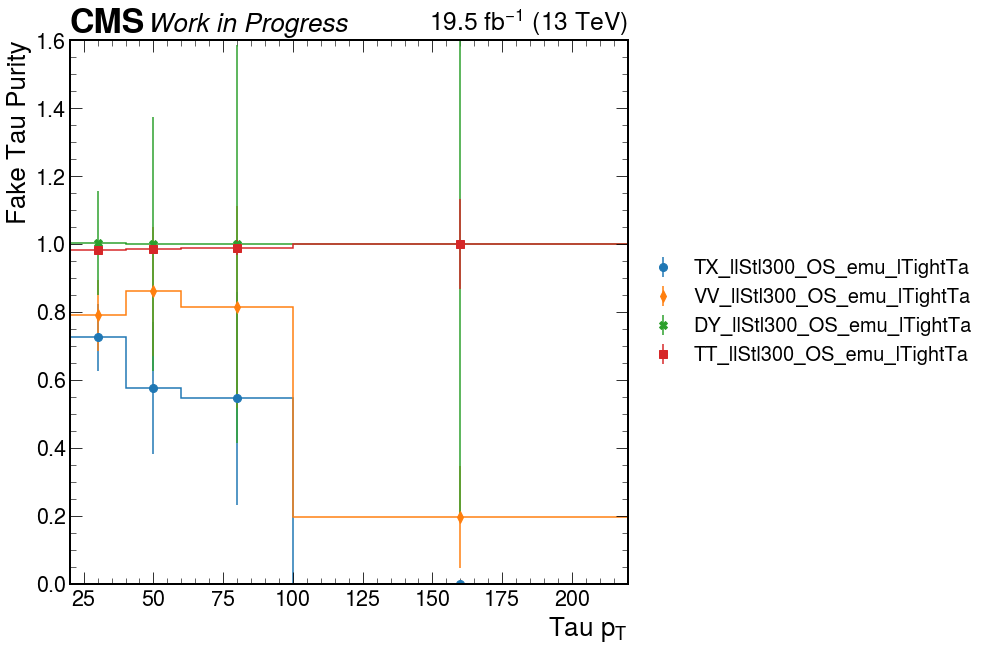

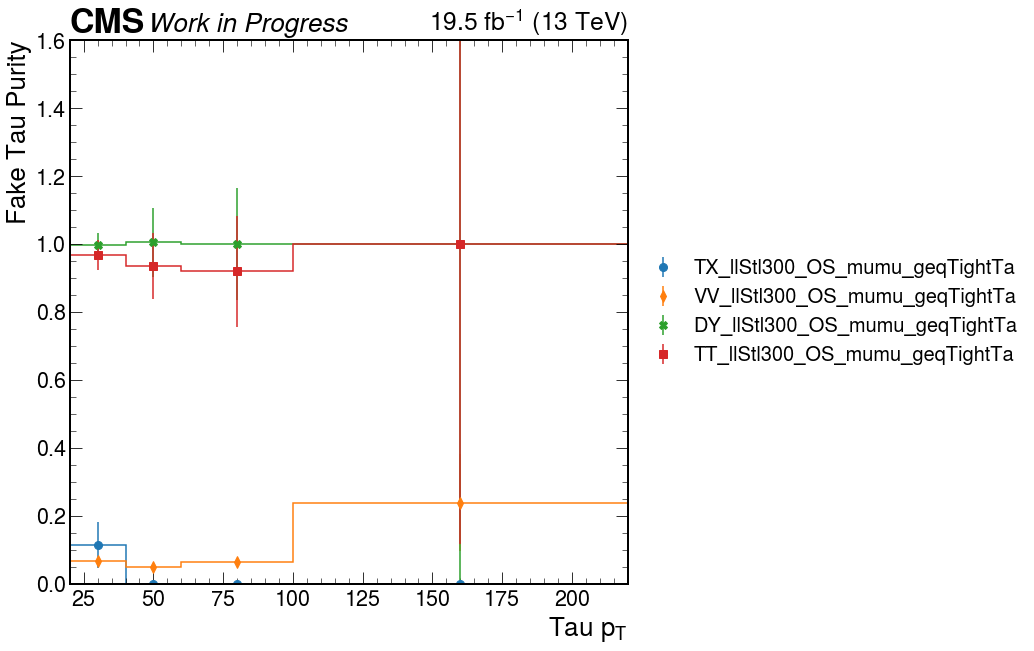

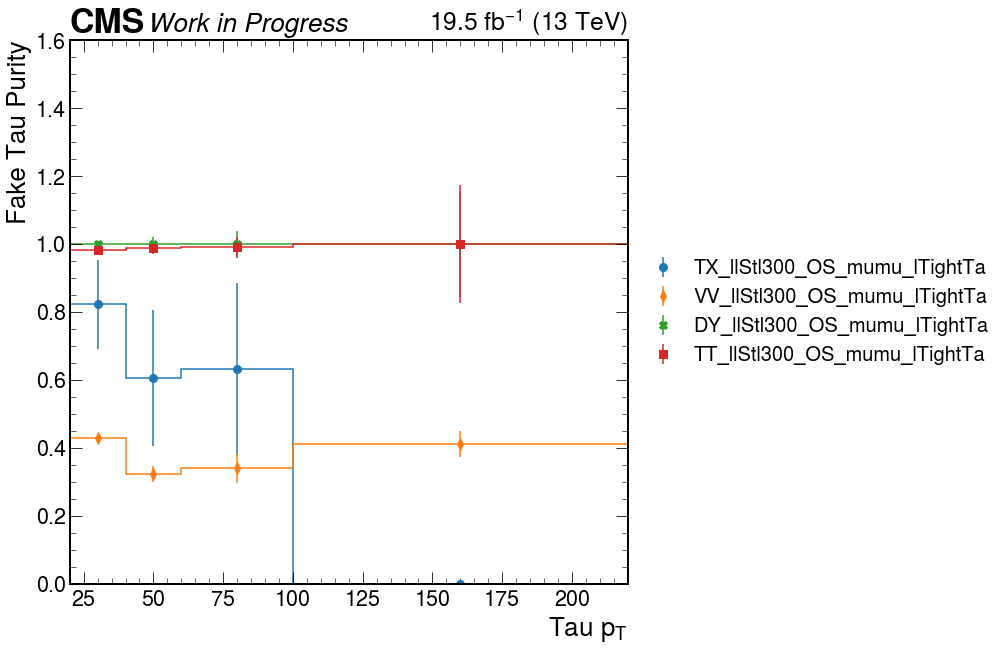

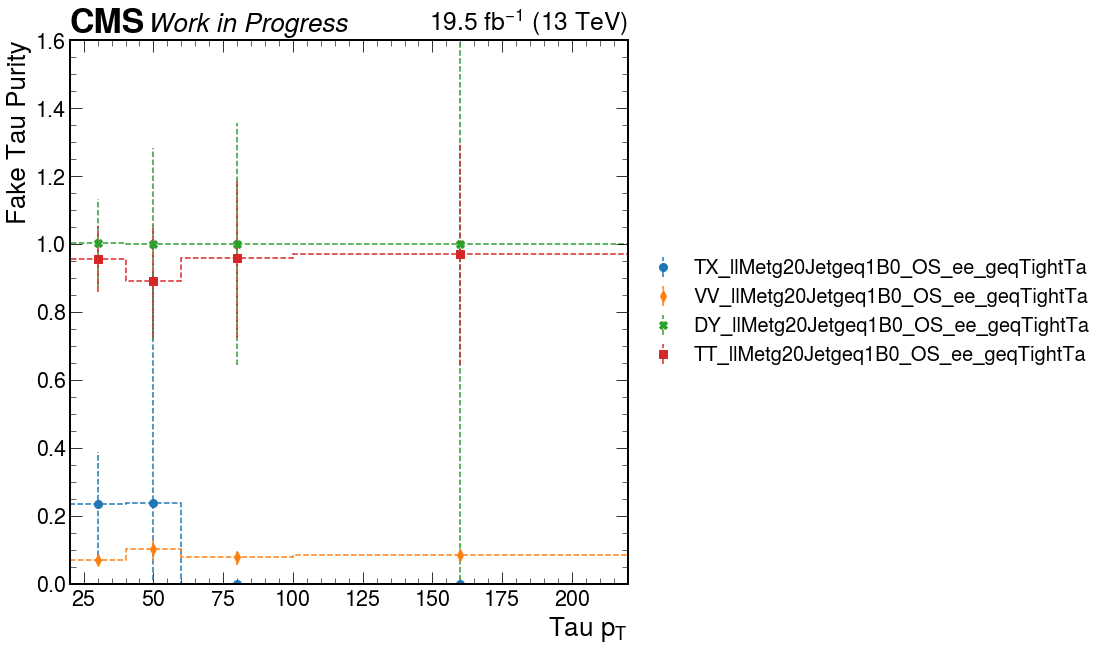

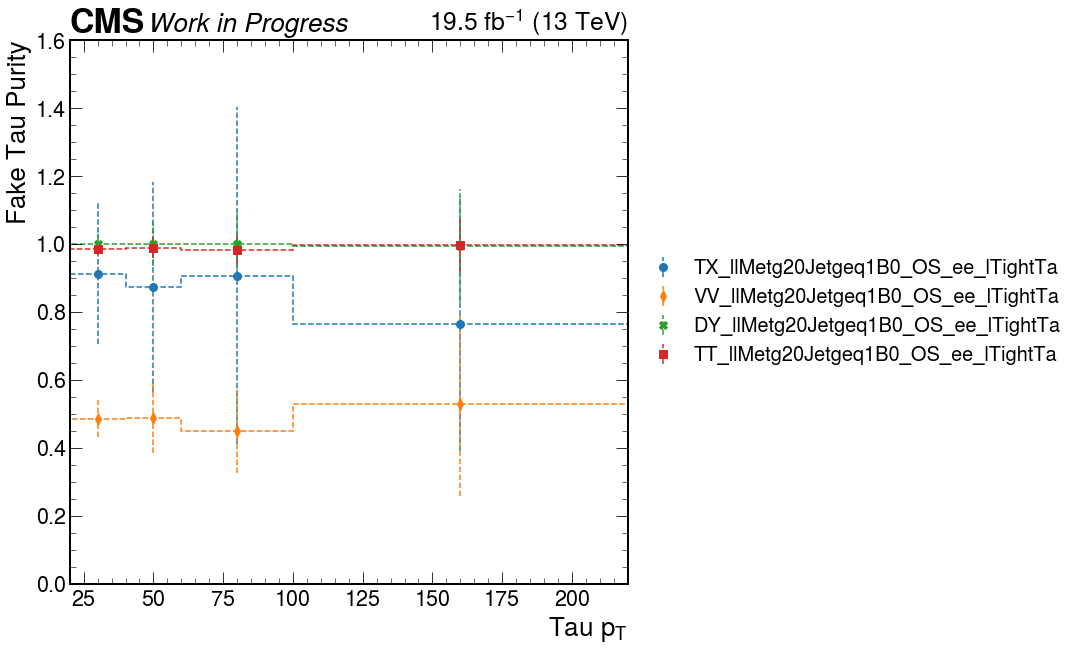

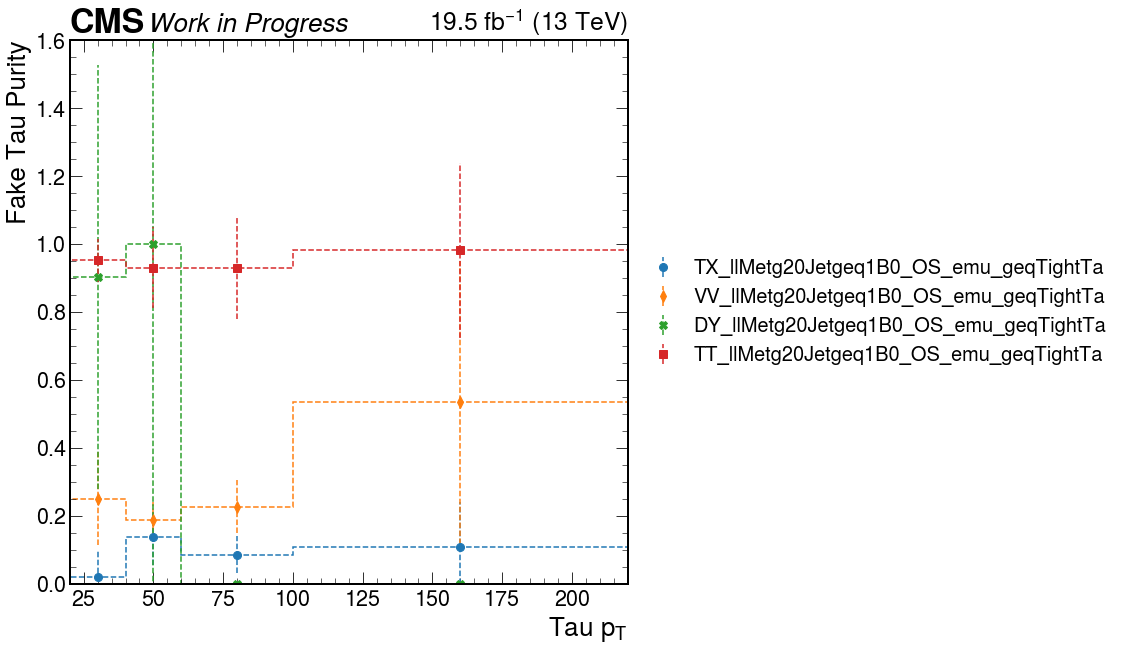

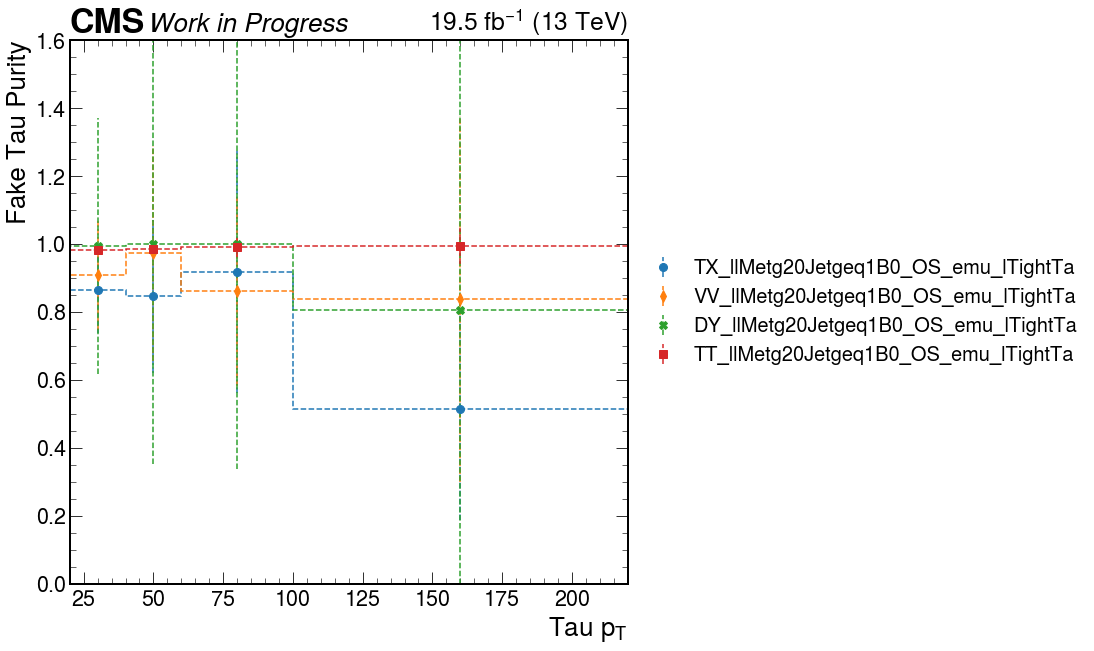

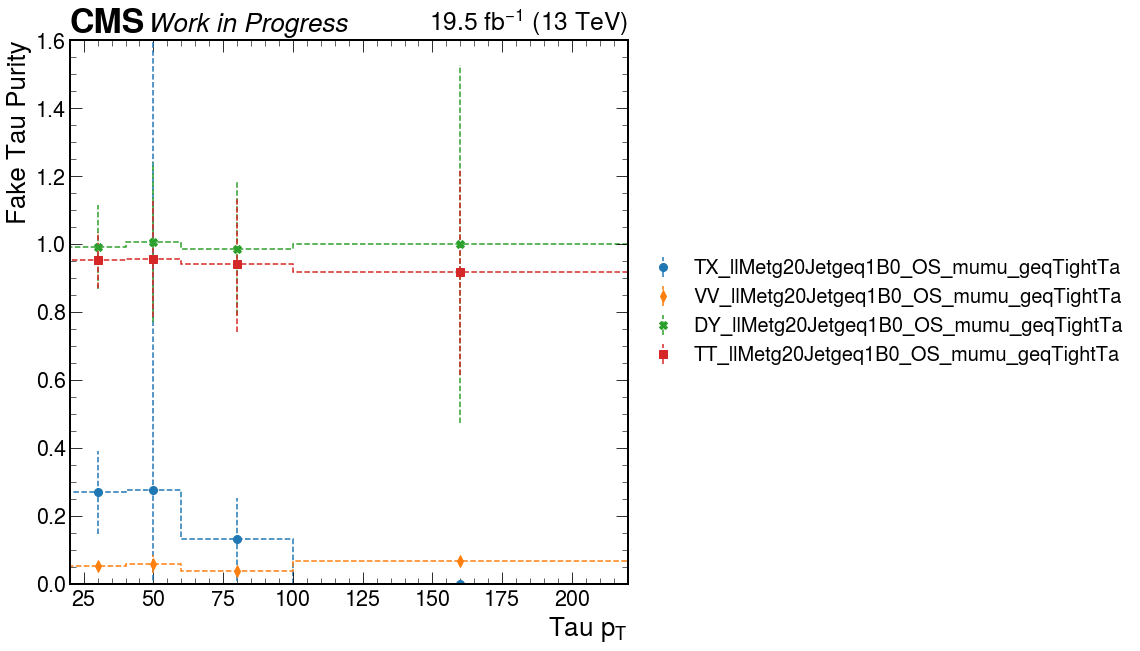

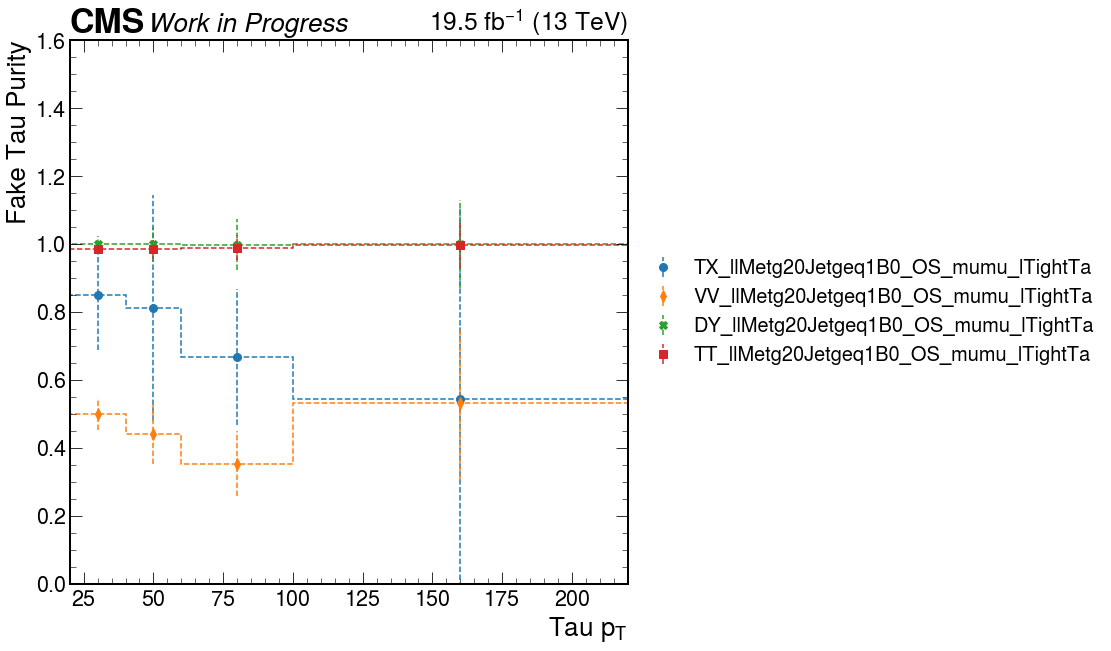

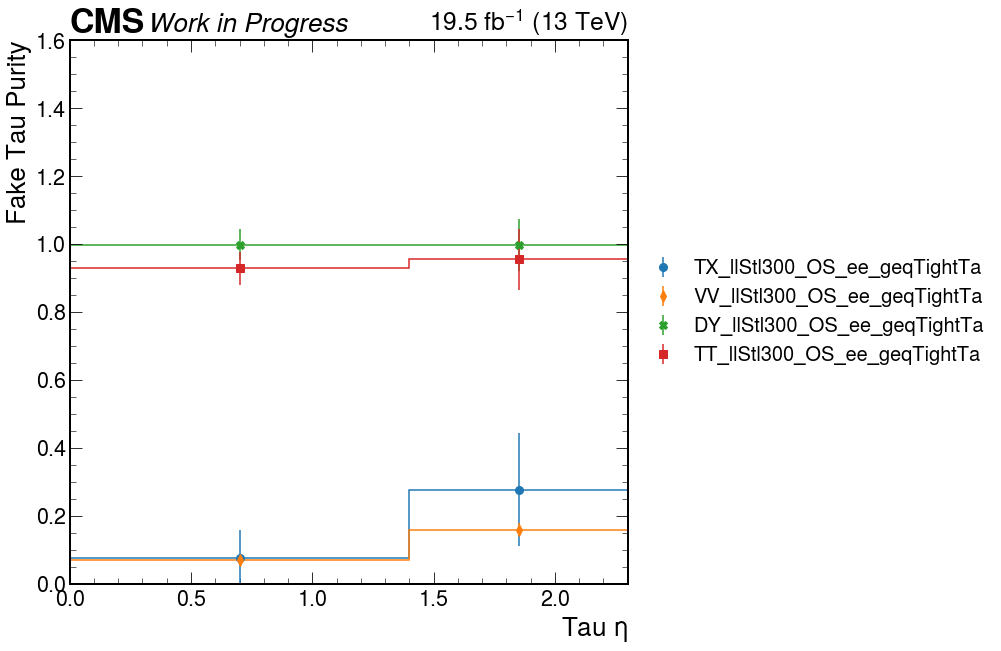

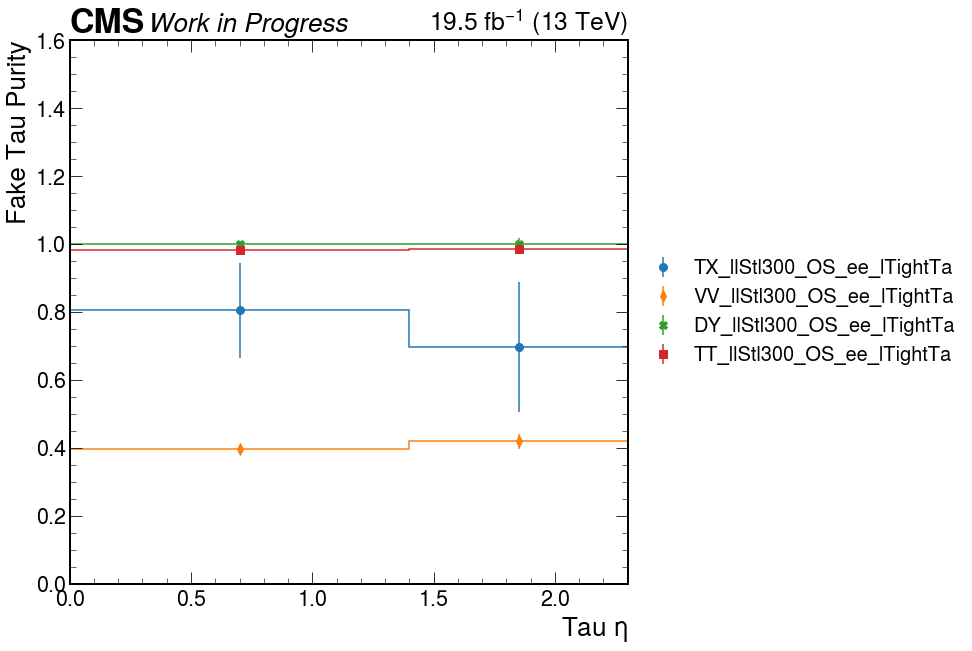

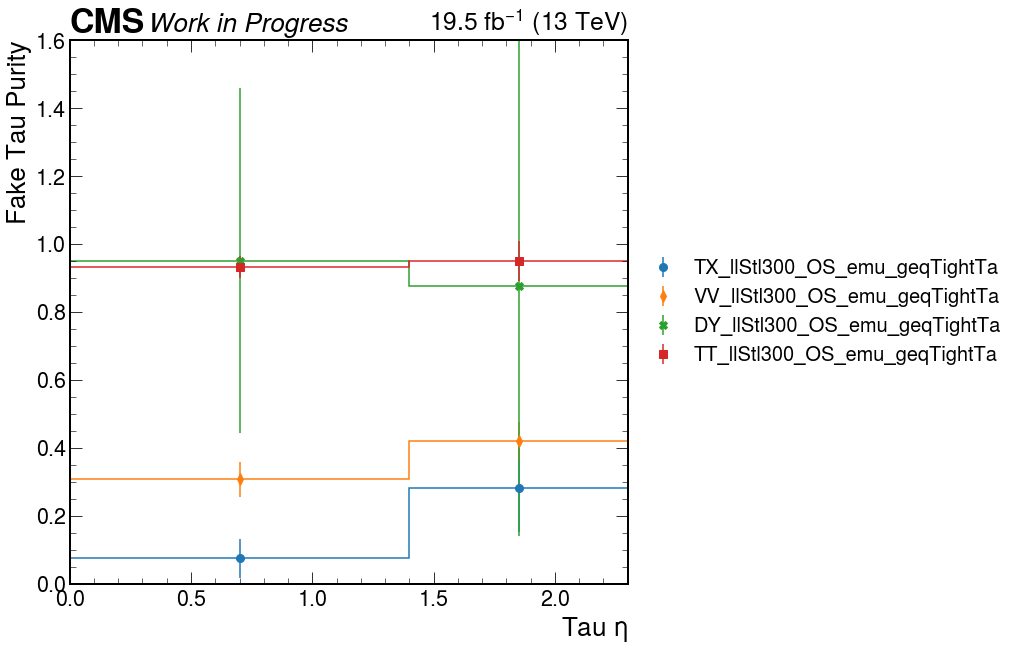

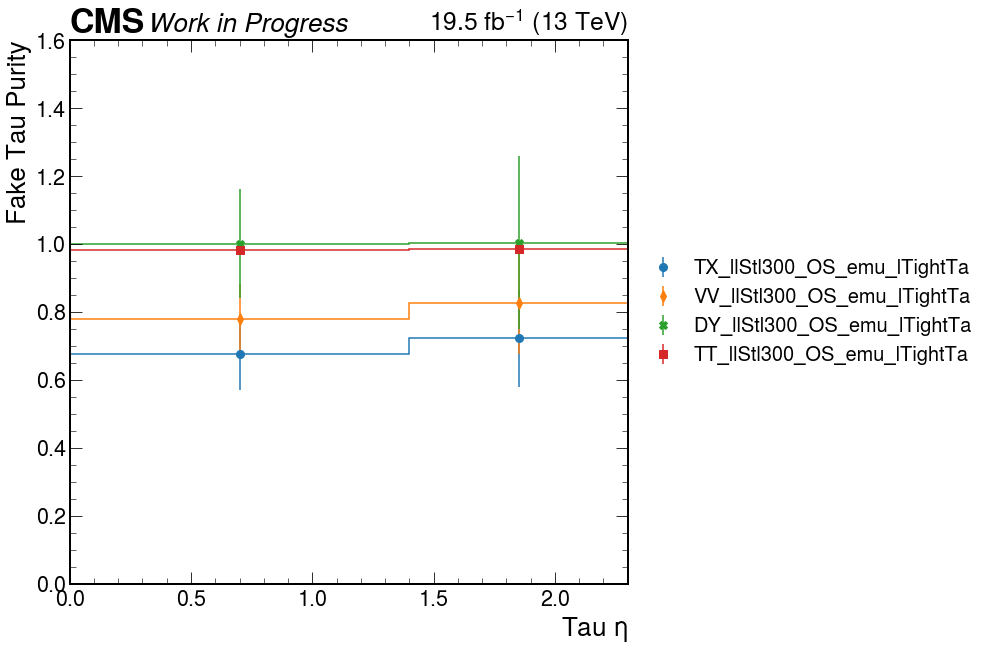

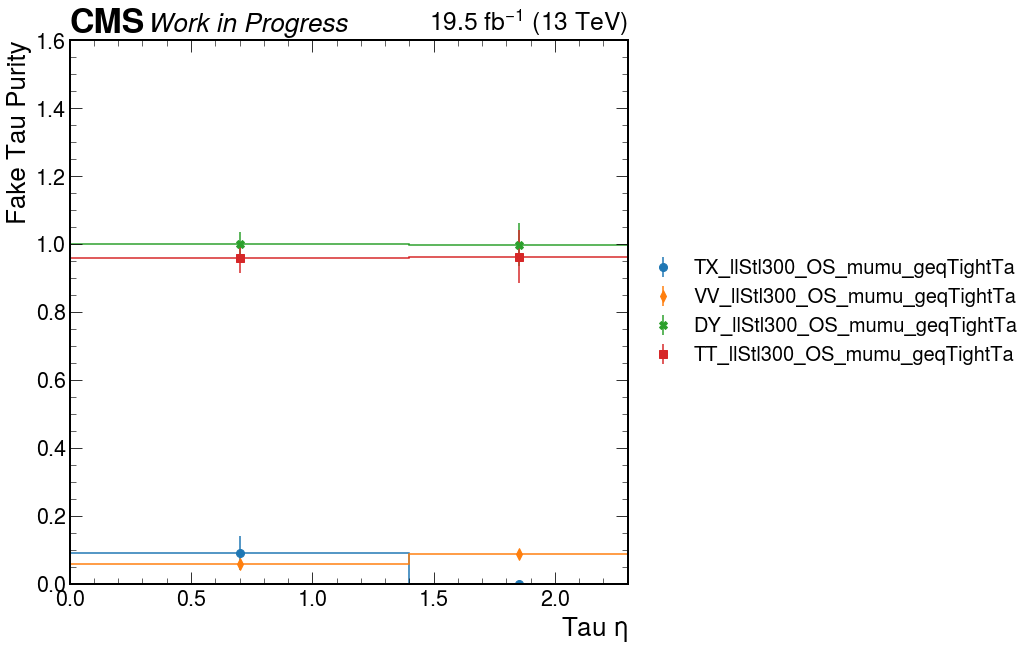

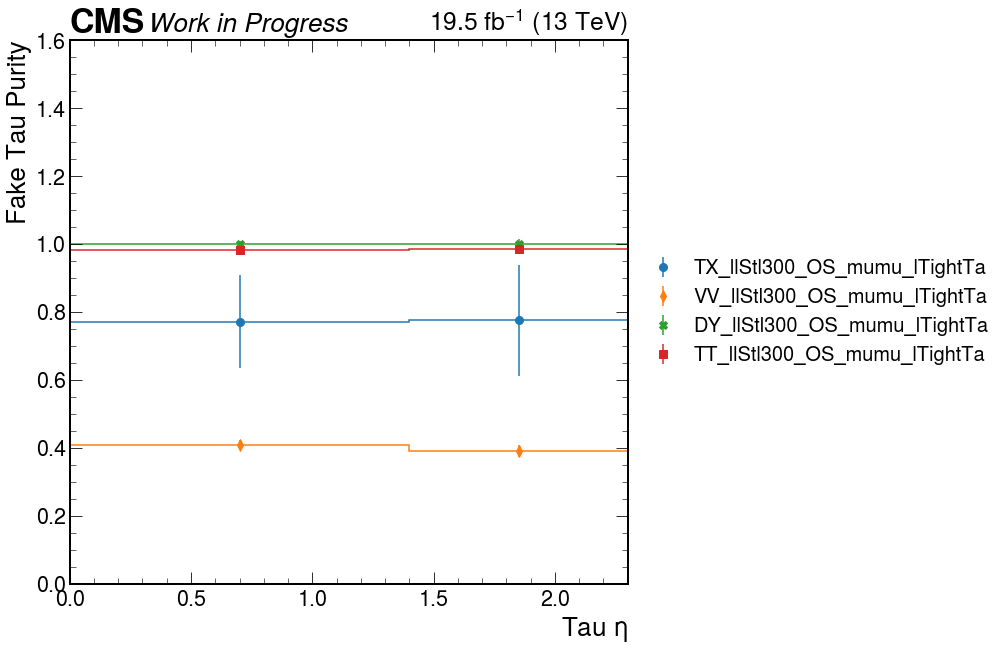

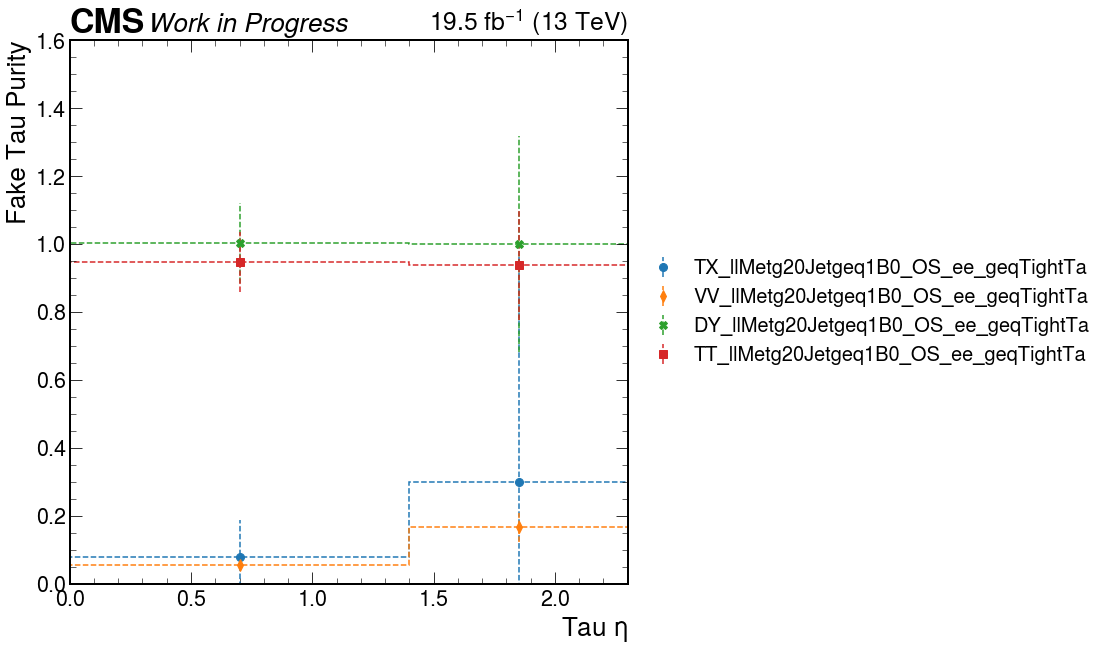

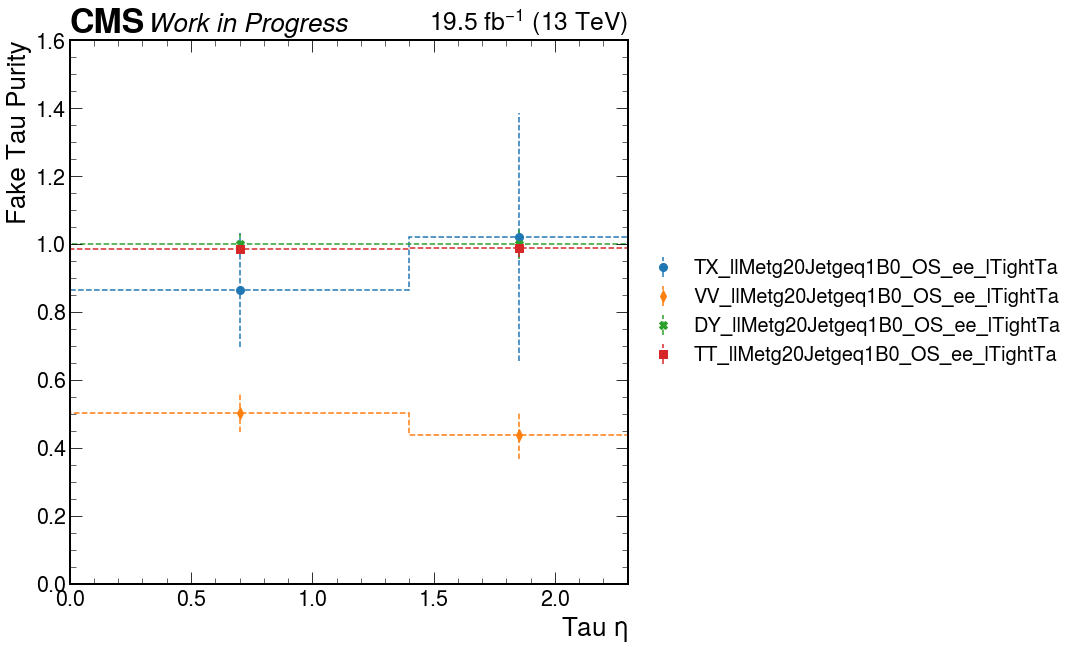

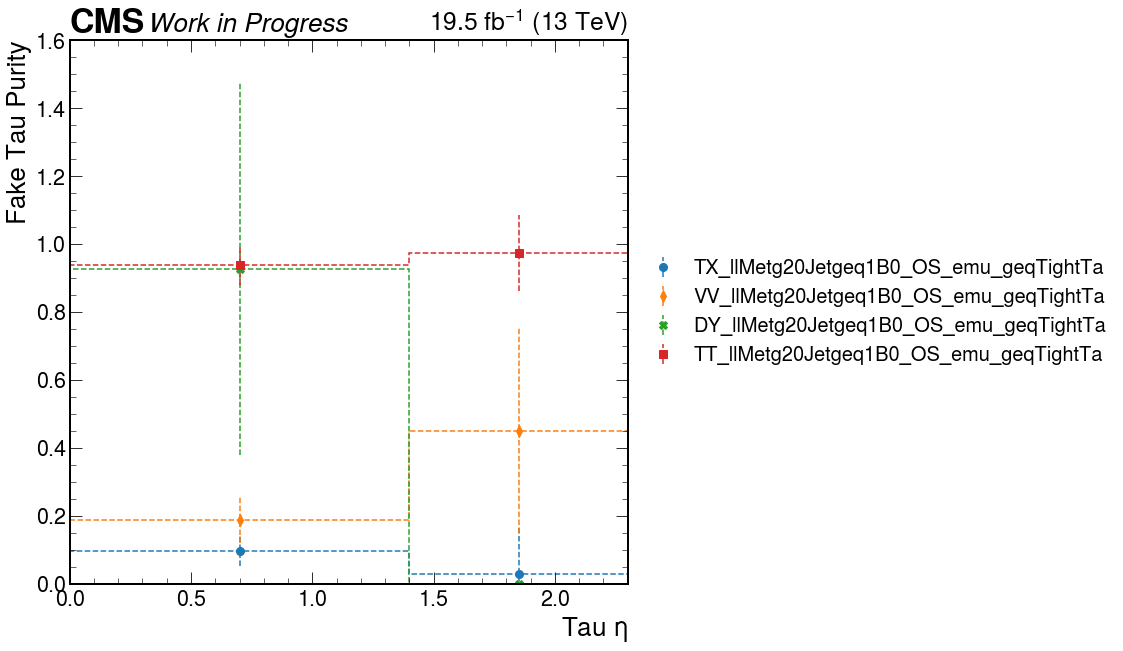

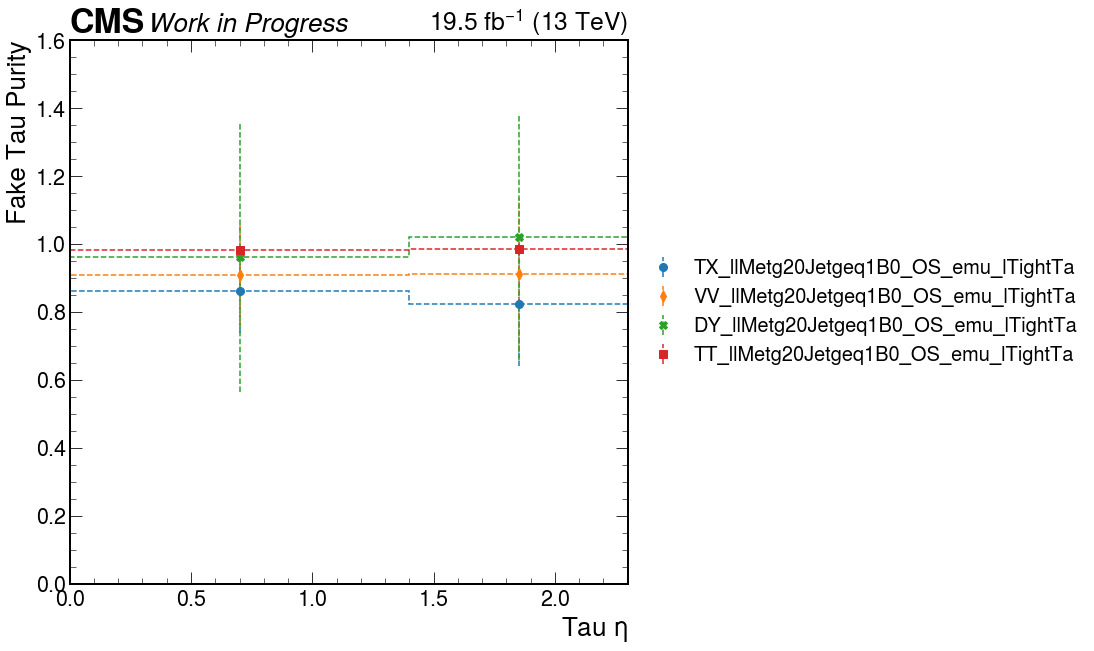

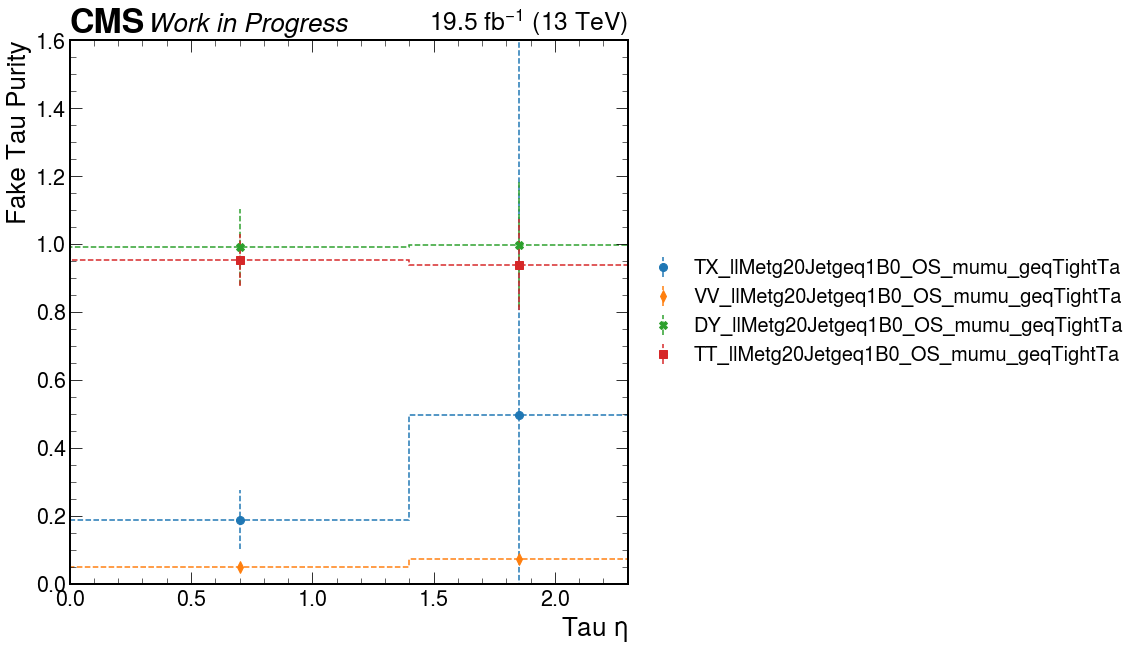

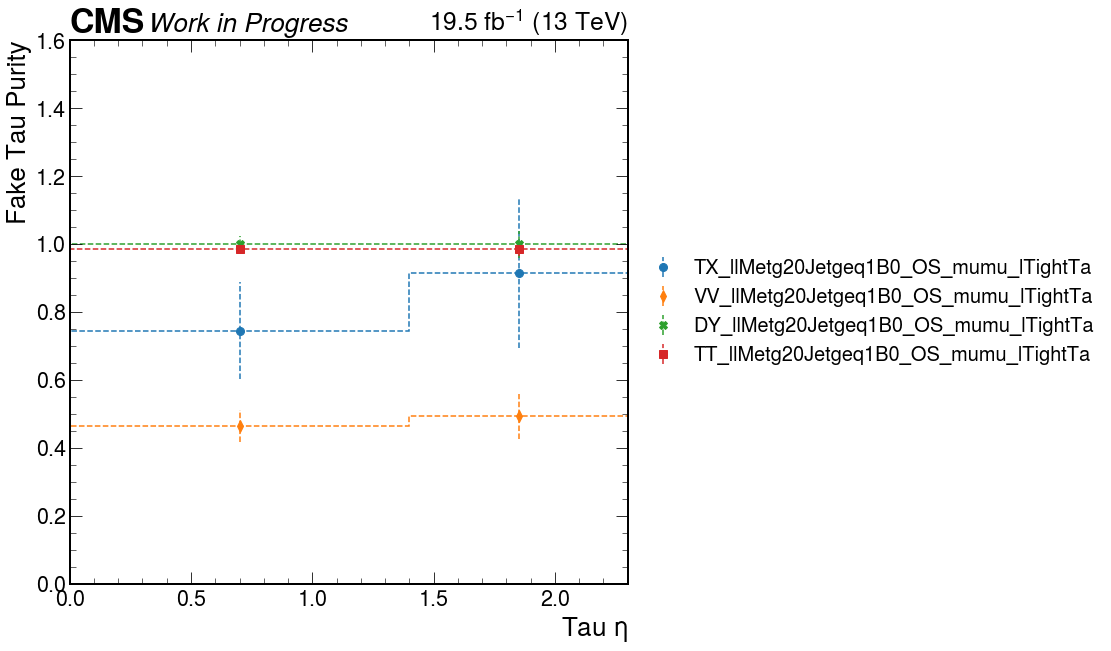

In [7]:
%%time

MARKERS = ["o", "d", "X", "s"]

for iyear, year in enumerate(YEARS):
    for idiff, diff in enumerate(DIFFS):
        if diff=="vsPt_vsEta": continue # 1D
        for region in REGIONS:
            if region=="ll": continue
            for charge in CHARGES:
                if charge=="SS": continue
                for channel in CHANNELS:
                    for ivar in range(0, len(VARS), 2):

                        iHist=0
                        hists=[]
                        errors=[]
                        bins=[]
                        labels=[]
                        linestyles=[]
                        linecolors=[]
                        fig, ax = plt.subplots(figsize=(10, 10))

                        for sample in SAMPLES:
                            if sample=="Data": continue
                            hname = year + "_" + sample + "_" + charge + "_" + channel + "_" + region + "_" + VARS[ivar+1] + "_" + diff
                            numerator = h[hname].Clone()
                            hname = year + "_" + sample + "_" + charge + "_" + channel + "_" + region + "_" + VARS[ivar] + "_" + diff
                            denominator = h[hname].Clone()
                            purity = numerator / denominator
                            purity.SetName(sample + "_" + region + "_" + charge + "_" + channel + "_" + VARS[ivar])
                            purity = uproot.from_pyroot(purity)

                            hists.append(purity.values())
                            errors.append(purity.errors())
                            labels.append(purity.name)
                            bins = purity.to_numpy()[1]
                            centers=[]
                            for iBin in range(len(bins) - 1):
                                centers.append((bins[iBin]+bins[iBin+1])/2)

                            ls = "solid"
                            if   region=="llStl300":          ls = "solid"
                            elif region=="llMetg20Jetgeq1B0": ls = "dashed"
                            lc = "C"+str(iHist)

                            error_bars = ax.errorbar(centers,
                                                     purity.values(),
                                                     yerr       = purity.errors(),
                                                     linestyle  = "None",
                                                     color      = lc,
                                                     marker     = MARKERS[iHist],
                                                     markersize = 8,
                                                     label      = purity.name
                            )
                            error_bars[-1][0].set_linestyle(ls)
                            linestyles.append(ls)
                            linecolors.append(lc)
                            iHist+=1

                        hep.histplot(hists,
                                     bins      = bins,
                                     linestyle = linestyles,
                                     color     = linecolors,
                                     ax        = ax
                        )

                        ax.set_xlim(DIFF_1DLIMS[idiff][0], DIFF_1DLIMS[idiff][1])
                        ax.set_ylim(0.0, 1.6) # max purity should be 1.0
                        ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=20)
                        ax.set_xlabel(DIFF_AXLABELS[idiff])
                        ax.set_ylabel(r"Fake Tau Purity")
                        hep.style.use("CMS")
                        hep.cms.label("Work in Progress", data=True, rlabel=LUMI[iyear]+r" $fb^{-1}$ (13 TeV)")
                        plt.savefig(year + "_" + region + "_" + charge + "_" + channel + "_" + VARS[ivar] + "_1Dpurity_" + diff + ".pdf", bbox_inches="tight")

2D fake tau purity

2016_DY_OS_ee_llStl300
2016_DY_OS_ee_llStl300
2016_DY_OS_emu_llStl300
2016_DY_OS_emu_llStl300
2016_DY_OS_mumu_llStl300
2016_DY_OS_mumu_llStl300
2016_DY_OS_ee_llMetg20Jetgeq1B0
2016_DY_OS_ee_llMetg20Jetgeq1B0
2016_DY_OS_emu_llMetg20Jetgeq1B0
2016_DY_OS_emu_llMetg20Jetgeq1B0
2016_DY_OS_mumu_llMetg20Jetgeq1B0
2016_DY_OS_mumu_llMetg20Jetgeq1B0
CPU times: user 9.81 s, sys: 5.67 s, total: 15.5 s
Wall time: 9.96 s


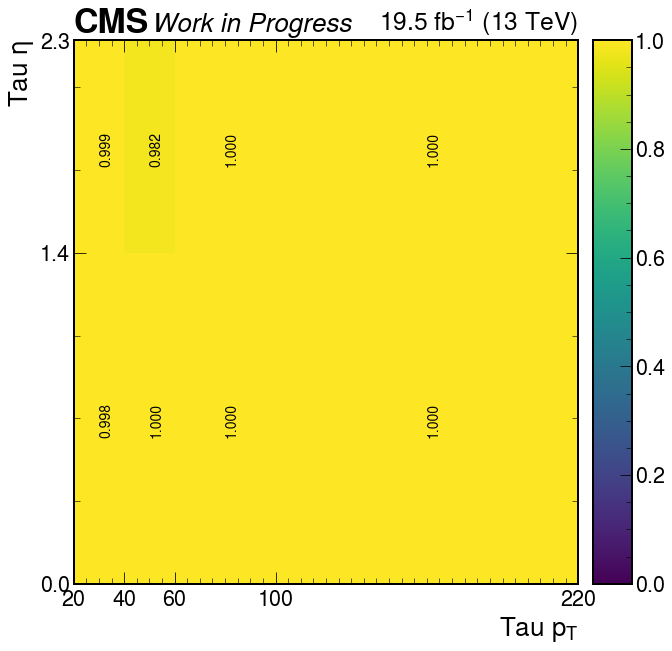

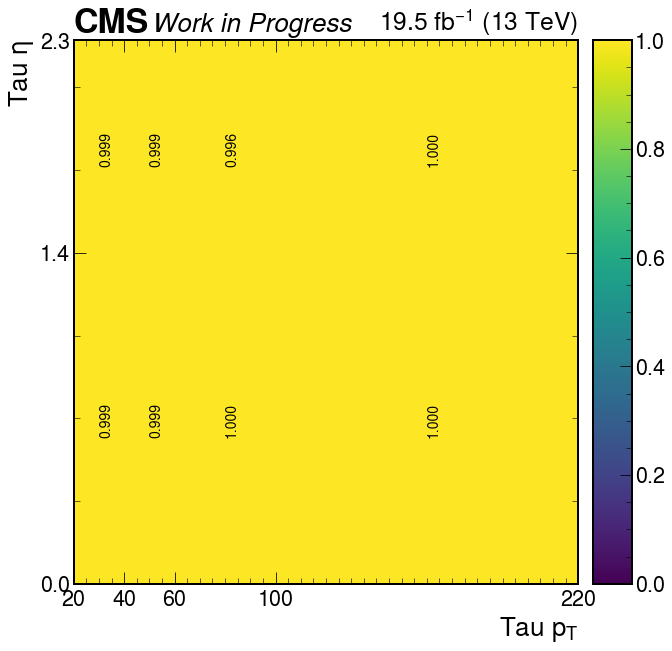

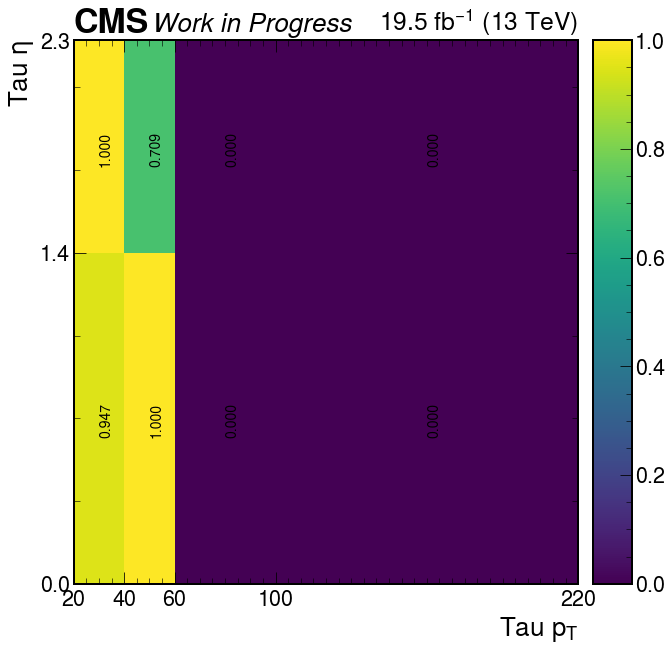

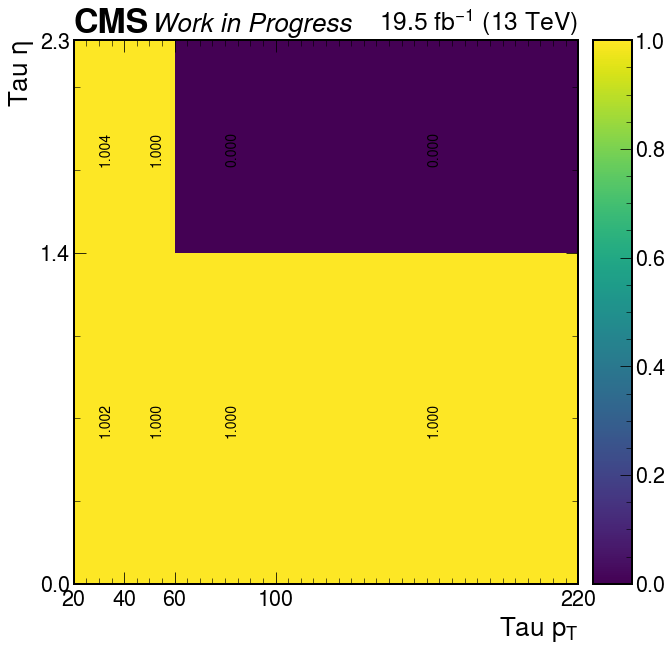

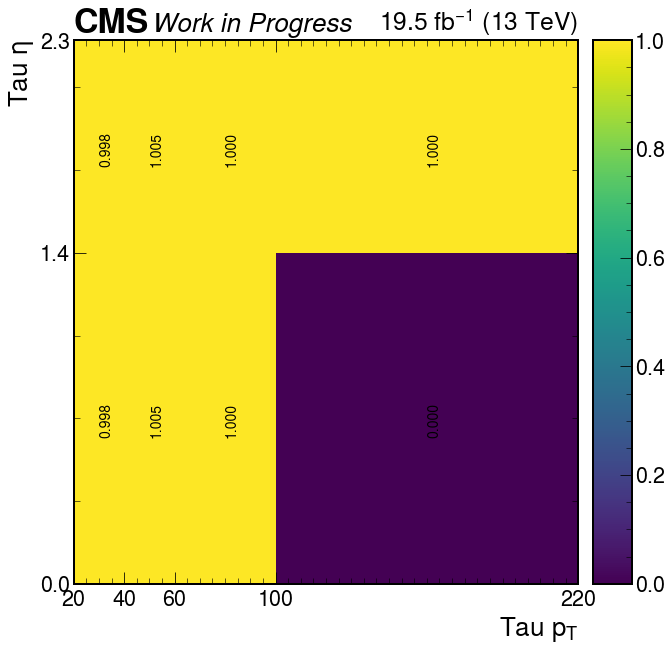

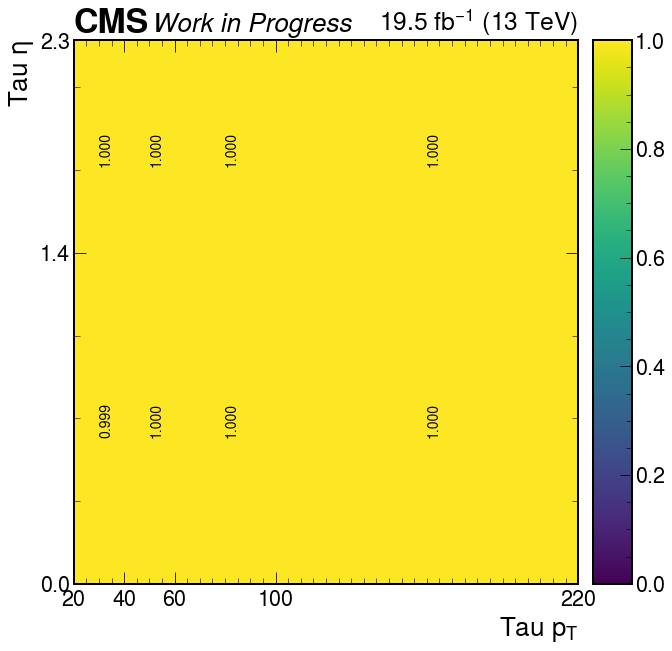

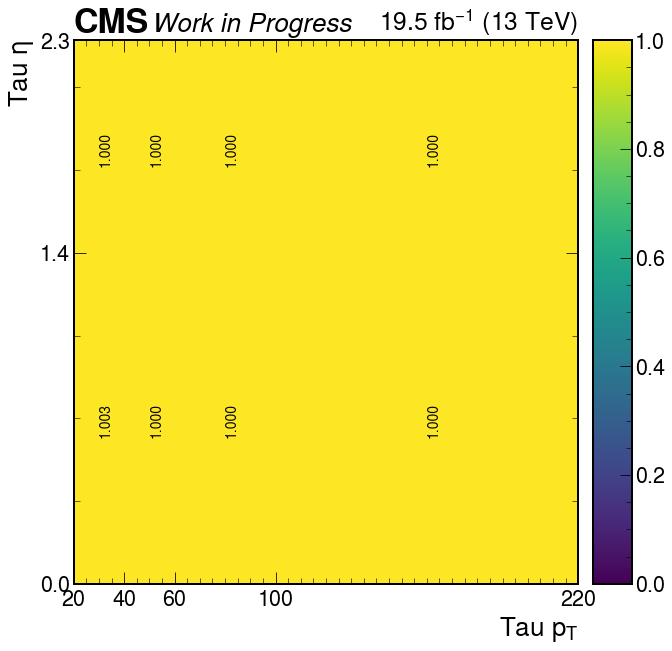

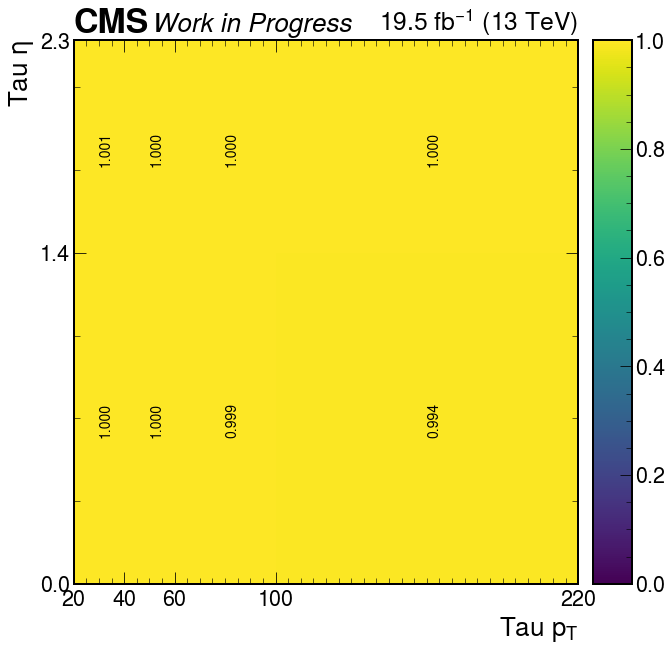

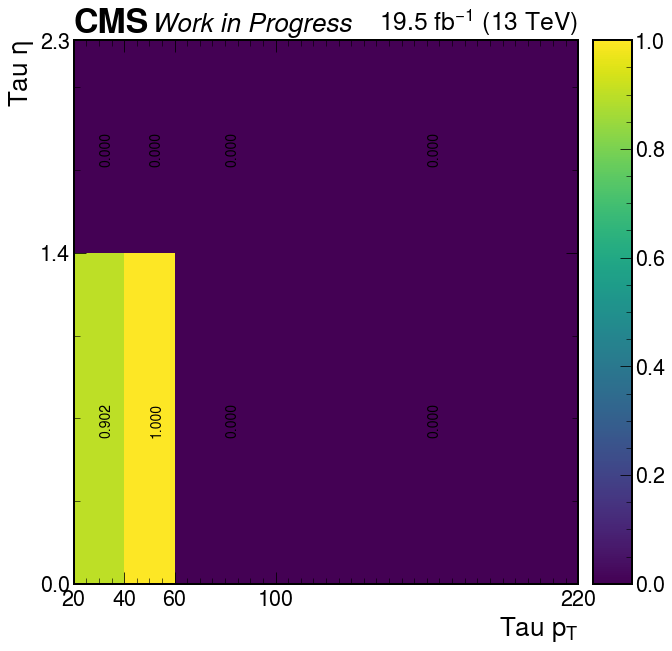

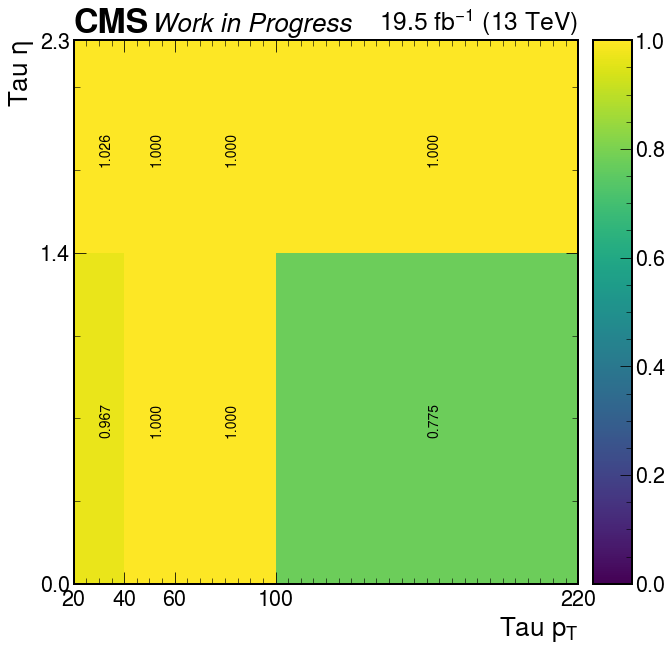

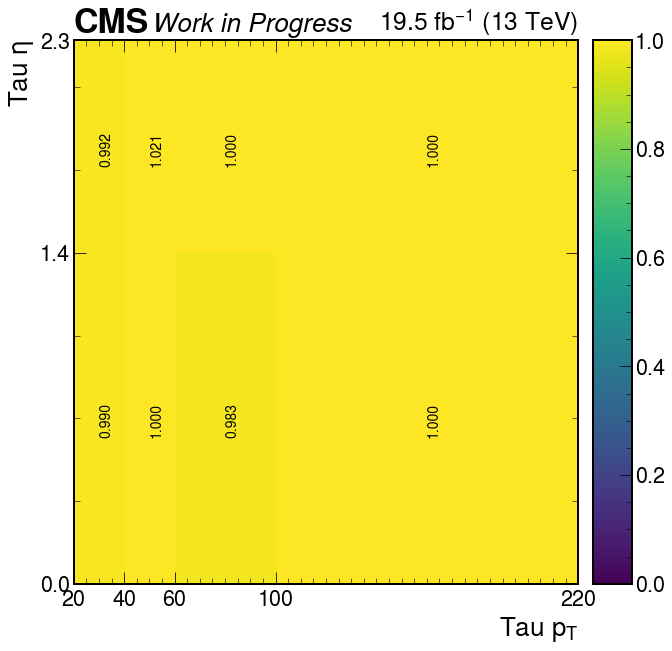

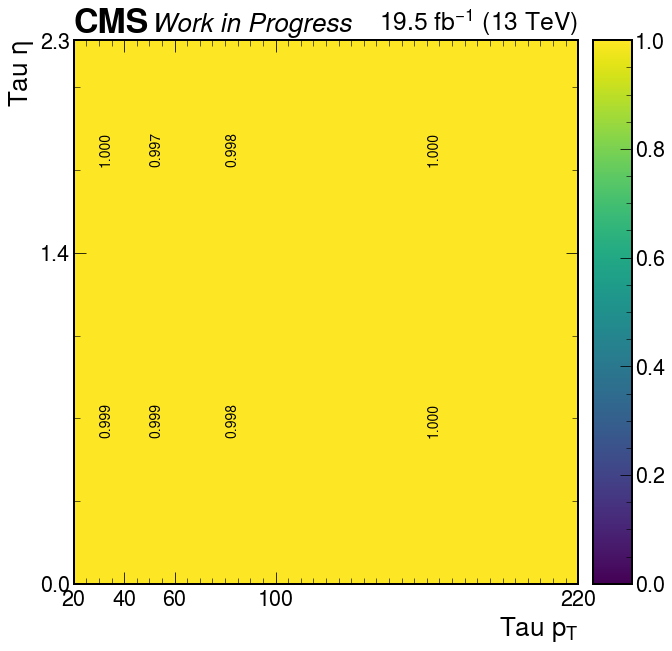

In [10]:
%%time
for iyear, year in enumerate(YEARS):
    for idiff, diff in enumerate(DIFFS):
        if diff!="vsPt_vsEta": continue # 2D
        for region in REGIONS:
            if region=="ll": continue
            for charge in CHARGES:
                if charge=="SS": continue
                for channel in CHANNELS:
                    for ivar in range(0, len(VARS), 2):
                        for sample in SAMPLES:
                            if sample=="Data": continue
                            if sample!="DY": continue
                            plt.figure()

                            print(year + "_" + sample + "_" + charge + "_" + channel + "_" + region)
                            hname = year + "_" + sample + "_" + charge + "_" + channel + "_" + region + "_" + VARS[ivar+1] + "_" + diff
                            numerator = h[hname].Clone()
                            hname = year + "_" + sample + "_" + charge + "_" + channel + "_" + region + "_" + VARS[ivar] + "_" + diff
                            denominator = h[hname].Clone()
                            numerator.Divide(denominator)
                            purity = uproot.from_pyroot(numerator).to_hist()
                            purity.plot(norm=clr.Normalize(vmin=0, vmax=1))
                            for ix, xbin in enumerate(purity.axes[0]):
                                xcoord = np.mean(xbin)
                                for iy, ybin in enumerate(purity.axes[1]):
                                    ycoord = np.mean(ybin)
                                    count = purity.counts()[ix][iy]
                                    count = "%.3f" % count
                                    plt.text(xcoord, ycoord-0.07, count, fontsize=14, rotation=90)

                            plt.xlabel(DIFF_AXLABELS[0])
                            plt.ylabel(DIFF_AXLABELS[1])
                            hep.style.use("CMS")
                            hep.cms.label("Work in Progress", data=True, rlabel=LUMI[iyear]+r" $fb^{-1}$ (13 TeV)")
                            plt.savefig(year + "_" + sample + "_" + region + "_" + charge + "_" + channel + "_" + VARS[ivar] + "_2Dpurity_" + diff + ".pdf", bbox_inches="tight")

1D fake factors all plotted together

CPU times: user 3.58 s, sys: 1.89 s, total: 5.47 s
Wall time: 3.54 s


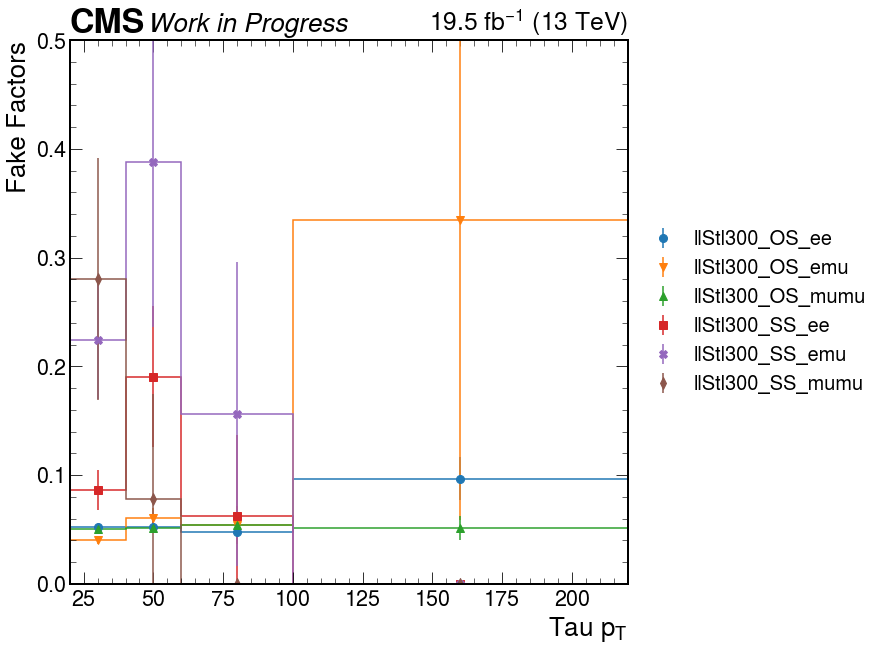

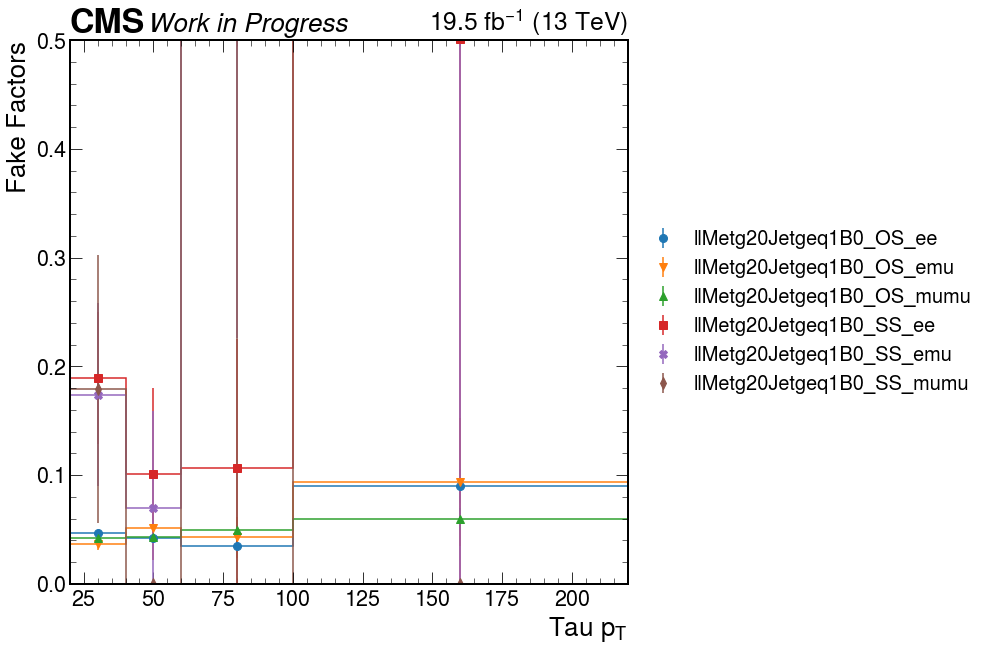

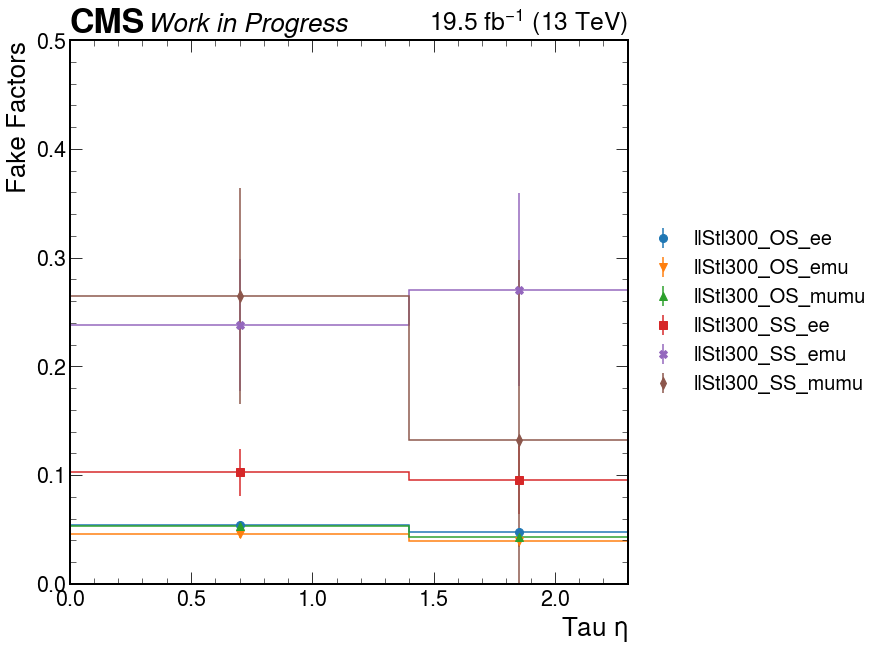

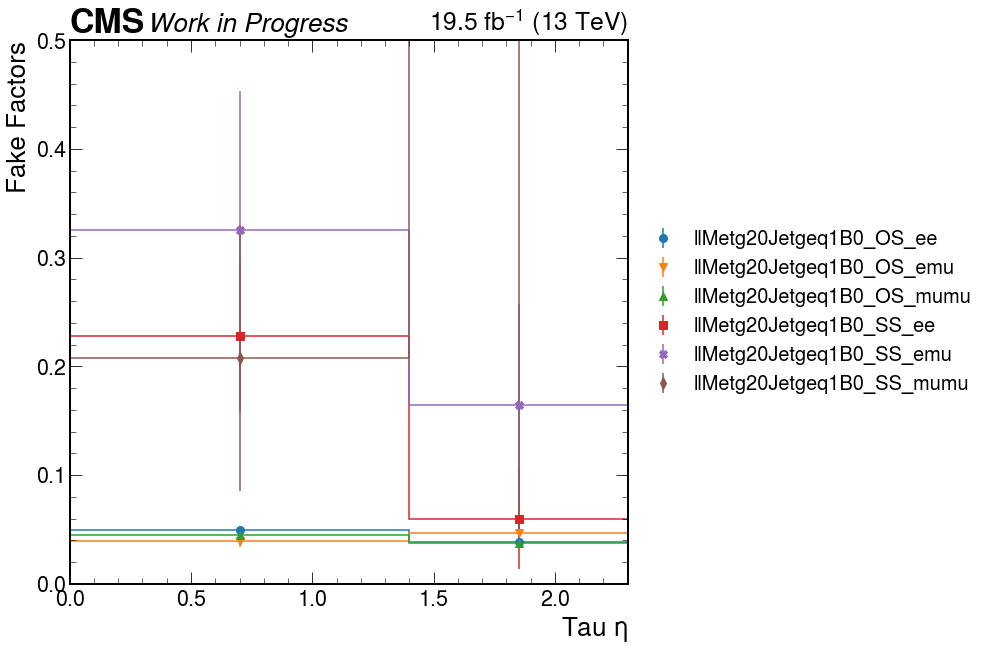

In [17]:
%%time

MARKERS = ["o", "v", "^", "s", "X", "d", "o", "v", "^", "s", "X", "d"]

for iyear, year in enumerate(YEARS):
    for idiff, diff in enumerate(DIFFS):
        if diff=="vsPt_vsEta": continue # 1D
        for region in REGIONS:
            if region=="ll": continue

            maxi=0.0
            iHist=0
            hists=[]
            errors=[]
            bins=[]
            labels=[]
            linestyles=[]
            linecolors=[]
            fig, ax = plt.subplots(figsize=(10, 10))

            for charge in CHARGES:
                for channel in CHANNELS:

                    hname = year + "_Data_" + charge + "_" + channel + "_" + region + "_geqTightTa_" + diff
                    numerator = h[hname].Clone()
                    hname = year + "_TX_" + charge + "_" + channel + "_" + region + "_geqTightTa_" + diff
                    numerator -= h[hname].Clone()
                    hname = year + "_VV_" + charge + "_" + channel + "_" + region + "_geqTightTa_" + diff
                    numerator -= h[hname].Clone()
                    for i in range(1, numerator.GetNbinsX() + 1): # Set negative event counts to 0
                        if numerator.GetBinContent(i) < 0.0:
                            numerator.SetBinContent(i, 0.0)
                            numerator.SetBinError(i, 0.0)

                    hname = year + "_Data_" + charge + "_" + channel + "_" + region + "_lTightTa_" + diff
                    denominator = h[hname].Clone()
                    hname = year + "_TX_" + charge + "_" + channel + "_" + region + "_lTightTa_" + diff
                    denominator -= h[hname].Clone()
                    hname = year + "_VV_" + charge + "_" + channel + "_" + region + "_lTightTa_" + diff
                    denominator -= h[hname].Clone()
                    for i in range(1, denominator.GetNbinsX() + 1): # Set negative event counts to 0
                        if denominator.GetBinContent(i) < 0.0:
                            denominator.SetBinContent(i, 0.0)
                            denominator.SetBinError(i, 0.0)

                    fake_factors = numerator / denominator
                    fake_factors.SetName(region + "_" + charge + "_" + channel)
                    fake_factors = uproot.from_pyroot(fake_factors)

                    maxi = max(maxi, fake_factors.values().max())
                    hists.append(fake_factors.values())
                    errors.append(fake_factors.errors())
                    labels.append(fake_factors.name)
                    bins = fake_factors.to_numpy()[1]
                    centers=[]
                    for iBin in range(len(bins) - 1):
                        centers.append((bins[iBin]+bins[iBin+1])/2)

                    ls = "solid"
                    if   region=="llStl300":          ls = "solid"
                    elif region=="llMetg20Jetgeq1B0": ls = "solid"
                    lc = "C"+str(iHist)

                    error_bars = ax.errorbar(centers,
                                             fake_factors.values(),
                                             yerr       = fake_factors.errors(),
                                             linestyle  = "None",
                                             color      = lc,
                                             marker     = MARKERS[iHist],
                                             markersize = 8,
                                             label      = fake_factors.name
                    )
                    error_bars[-1][0].set_linestyle(ls)
                    linestyles.append(ls)
                    linecolors.append(lc)
                    iHist+=1

            hep.histplot(hists,
                         bins      = bins,
                         linestyle = linestyles,
                         color     = linecolors,
                         ax        = ax
            )

            ax.set_xlim(DIFF_1DLIMS[idiff][0], DIFF_1DLIMS[idiff][1])
            ax.set_ylim(0.0, 0.5)
            # ax.set_ylim(3e-2, 5.0)
            # ax.set_yscale('log')
            ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=20)
            ax.set_xlabel(DIFF_AXLABELS[idiff])
            ax.set_ylabel(r"Fake Factors")
            hep.style.use("CMS")
            hep.cms.label("Work in Progress", data=True, rlabel=LUMI[iyear]+r" $fb^{-1}$ (13 TeV)")
            plt.savefig(year + "_" + region + "_1Dff_" + diff + ".pdf", bbox_inches="tight")

2D fake factors

CPU times: user 5.6 s, sys: 2.83 s, total: 8.43 s
Wall time: 6.31 s


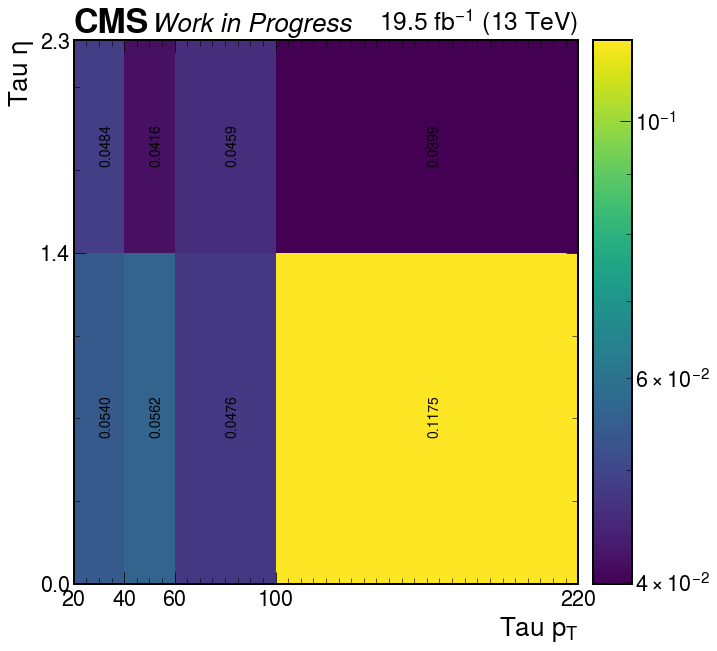

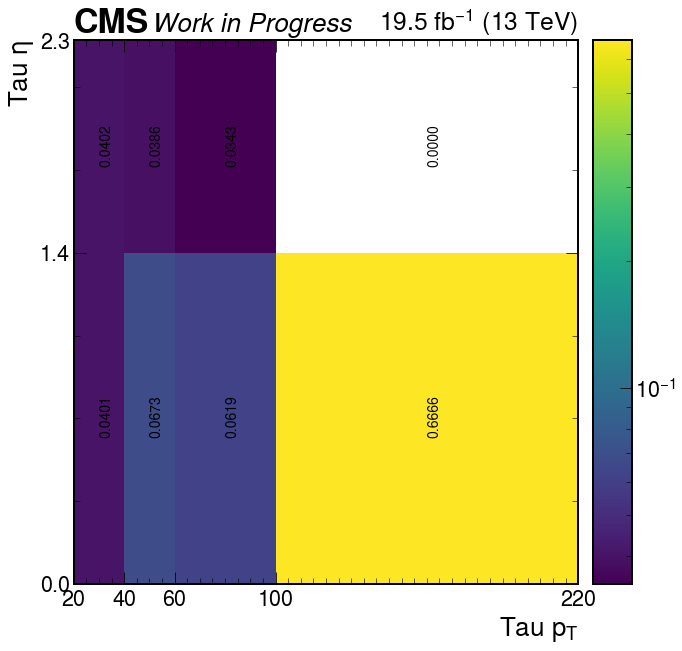

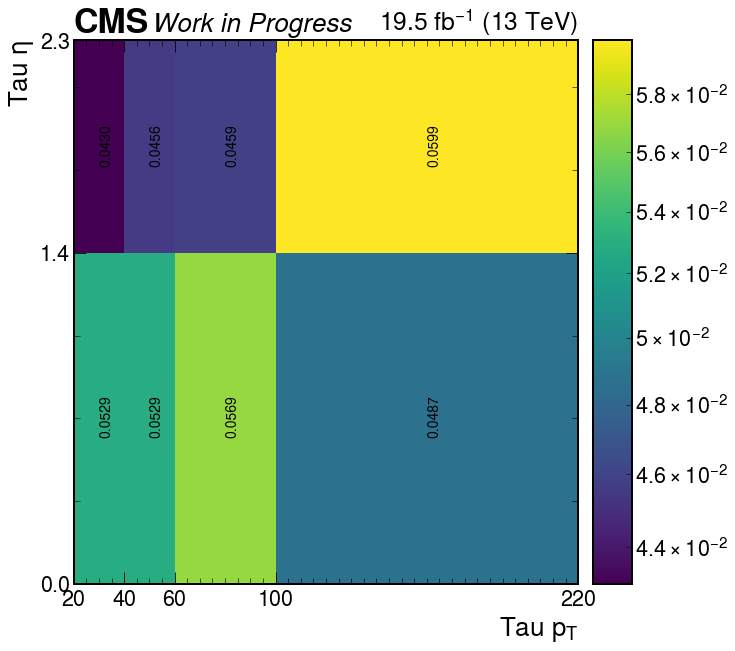

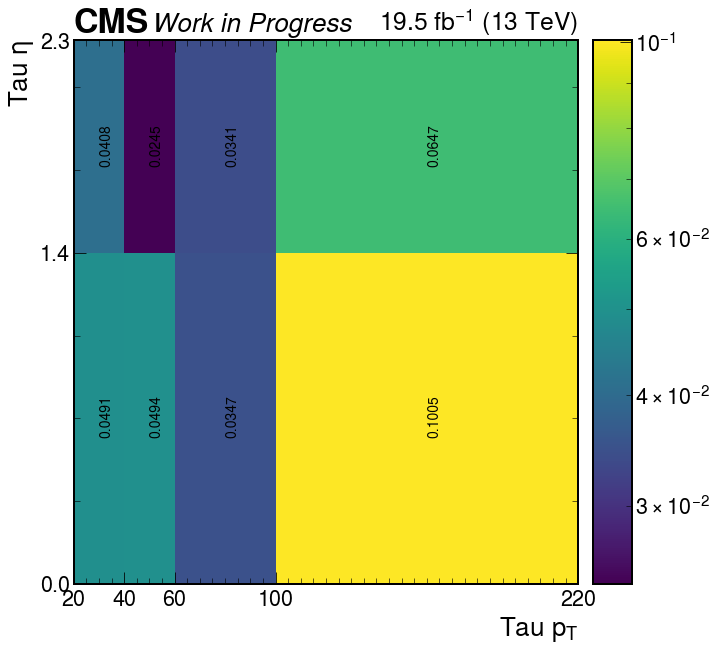

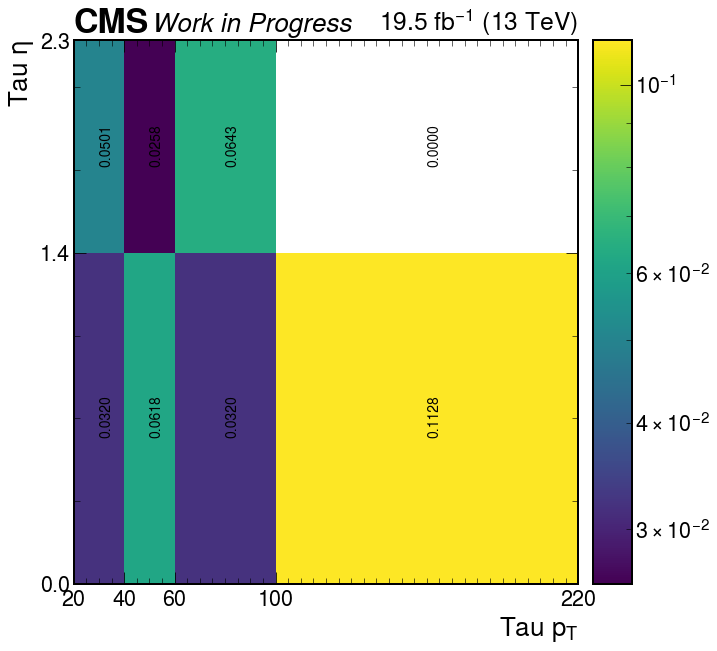

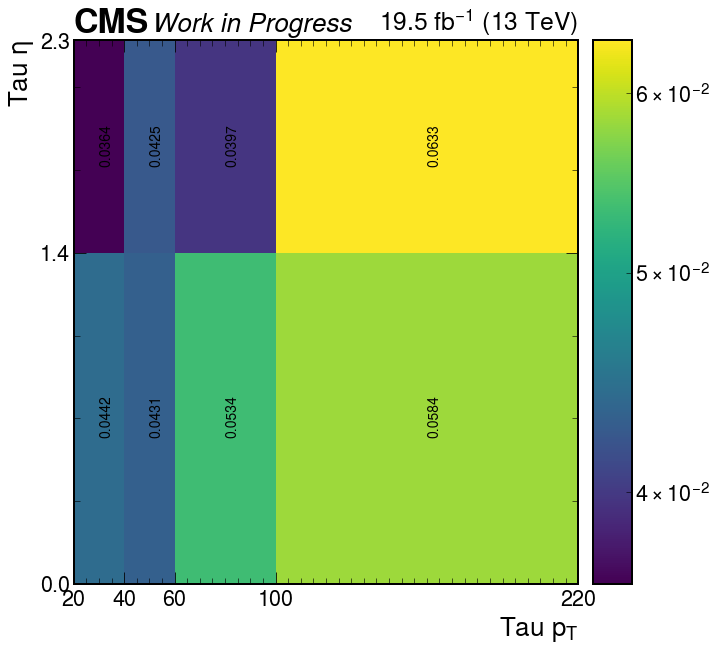

In [11]:
%%time
for iyear, year in enumerate(YEARS):
    for idiff, diff in enumerate(DIFFS):
        if diff!="vsPt_vsEta": continue # 2D
        for region in REGIONS:
            if region=="ll": continue
            for charge in CHARGES:
                if charge=="SS": continue
                for channel in CHANNELS:
                    plt.figure()

                    hname = year + "_Data_" + charge + "_" + channel + "_" + region + "_geqTightTa_" + diff
                    numerator = h[hname].Clone()
                    hname = year + "_TX_" + charge + "_" + channel + "_" + region + "_geqTightTa_" + diff
                    numerator.Add(h[hname].Clone(), -1.0)
                    hname = year + "_VV_" + charge + "_" + channel + "_" + region + "_geqTightTa_" + diff
                    numerator.Add(h[hname].Clone(), -1.0)
                    for i in range(1, numerator.GetNbinsX() + 1):
                        for j in range(1, numerator.GetNbinsY() + 1):
                            if numerator.GetBinContent(i, j) < 0.0:
                                numerator.SetBinContent(i, j, 0.0)
                                numerator.SetBinError(i, j, 0.0)

                    hname = year + "_Data_" + charge + "_" + channel + "_" + region + "_lTightTa_" + diff
                    denominator = h[hname].Clone()
                    hname = year + "_TX_" + charge + "_" + channel + "_" + region + "_lTightTa_" + diff
                    denominator.Add(h[hname].Clone(), -1.0)
                    hname = year + "_VV_" + charge + "_" + channel + "_" + region + "_lTightTa_" + diff
                    denominator.Add(h[hname].Clone(), -1.0)
                    for i in range(1, denominator.GetNbinsX() + 1):
                        for j in range(1, denominator.GetNbinsY() + 1):
                            if denominator.GetBinContent(i, j) < 0.0:
                                denominator.SetBinContent(i, j, 0.0)
                                denominator.SetBinError(i, j, 0.0)

                    numerator.Divide(denominator)
                    fake_factors = uproot.from_pyroot(numerator).to_hist()
                    fake_factors.plot(norm=clr.LogNorm())
                    for ix, xbin in enumerate(fake_factors.axes[0]):
                        xcoord = np.mean(xbin)
                        for iy, ybin in enumerate(fake_factors.axes[1]):
                            ycoord = np.mean(ybin)
                            count = fake_factors.counts()[ix][iy]
                            if count>10000: count = "%d" % count
                            elif count>1000: count = "%.1f" % count
                            elif count>100: count = "%.2f" % count
                            elif count>10: count = "%.3f" % count
                            else: count = "%.4f" % count
                            plt.text(xcoord, ycoord-0.07, count, fontsize=14, rotation=90)

                    plt.xlabel(DIFF_AXLABELS[0])
                    plt.ylabel(DIFF_AXLABELS[1])
                    hep.style.use("CMS")
                    hep.cms.label("Work in Progress", data=True, rlabel=LUMI[iyear]+r" $fb^{-1}$ (13 TeV)")
                    plt.savefig(year + "_" + region + "_" + charge + "_" + channel + "_2Dff_" + diff + ".pdf", bbox_inches="tight")